In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
%matplotlib inline

# Loading Data set

In [2]:
df = pd.read_csv("HousingData.csv")
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


# prepare data set

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [4]:
df.rename(columns={"MEDV": "price"}, inplace=True)

In [5]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [6]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
price       0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,394.0,3.690136,9.202423,0.00632,0.081955,0.26888,3.435973,88.9762
ZN,394.0,11.460660,23.954082,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,394.0,11.000863,6.908364,0.46000,5.130000,8.56000,18.100000,27.7400
CHAS,394.0,0.068528,0.252971,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,394.0,0.553215,0.113112,0.38900,0.453000,0.53800,0.624000,0.8710
RM,394.0,6.280015,0.697985,3.56100,5.879250,6.20150,6.605500,8.7800
AGE,394.0,68.932741,27.888705,2.90000,45.475000,77.70000,94.250000,100.0000
DIS,394.0,3.805268,2.098571,1.12960,2.110100,3.19920,5.116700,12.1265
RAD,394.0,9.403553,8.633451,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,394.0,406.431472,168.312419,187.00000,280.250000,330.00000,666.000000,711.0000


# EDA

In [10]:
df.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
CRIM,1.000000,-0.188075,0.391552,-0.051970,0.416160,-0.227170,0.341311,-0.365052,0.608667,0.560841,0.265428,-0.386254,0.461906,-0.397230
ZN,-0.188075,1.000000,-0.521256,-0.033357,-0.515660,0.343210,-0.568174,0.645359,-0.298773,-0.305768,-0.422164,0.169894,-0.415041,0.406822
INDUS,0.391552,-0.521256,1.000000,0.049820,0.762737,-0.403068,0.642387,-0.696569,0.591944,0.734204,0.395691,-0.344788,0.598156,-0.510829
CHAS,-0.051970,-0.033357,0.049820,1.000000,0.076661,0.095308,0.072644,-0.095037,0.014102,-0.026513,-0.104995,0.068913,-0.037113,0.173701
NOX,0.416160,-0.515660,0.762737,0.076661,1.000000,-0.316563,0.732540,-0.768137,0.628170,0.679824,0.210216,-0.384257,0.593655,-0.459054
RM,-0.227170,0.343210,-0.403068,0.095308,-0.316563,1.000000,-0.248670,0.218713,-0.236057,-0.320561,-0.390686,0.123320,-0.636226,0.723951
AGE,0.341311,-0.568174,0.642387,0.072644,0.732540,-0.248670,1.000000,-0.753547,0.443585,0.504472,0.264968,-0.281990,0.601137,-0.407470
DIS,-0.365052,0.645359,-0.696569,-0.095037,-0.768137,0.218713,-0.753547,1.000000,-0.477075,-0.529603,-0.228840,0.285168,-0.505036,0.279547
RAD,0.608667,-0.298773,0.591944,0.014102,0.628170,-0.236057,0.443585,-0.477075,1.000000,0.900000,0.441949,-0.444135,0.510868,-0.416638
TAX,0.560841,-0.305768,0.734204,-0.026513,0.679824,-0.320561,0.504472,-0.529603,0.900000,1.000000,0.446961,-0.435457,0.572218,-0.508864


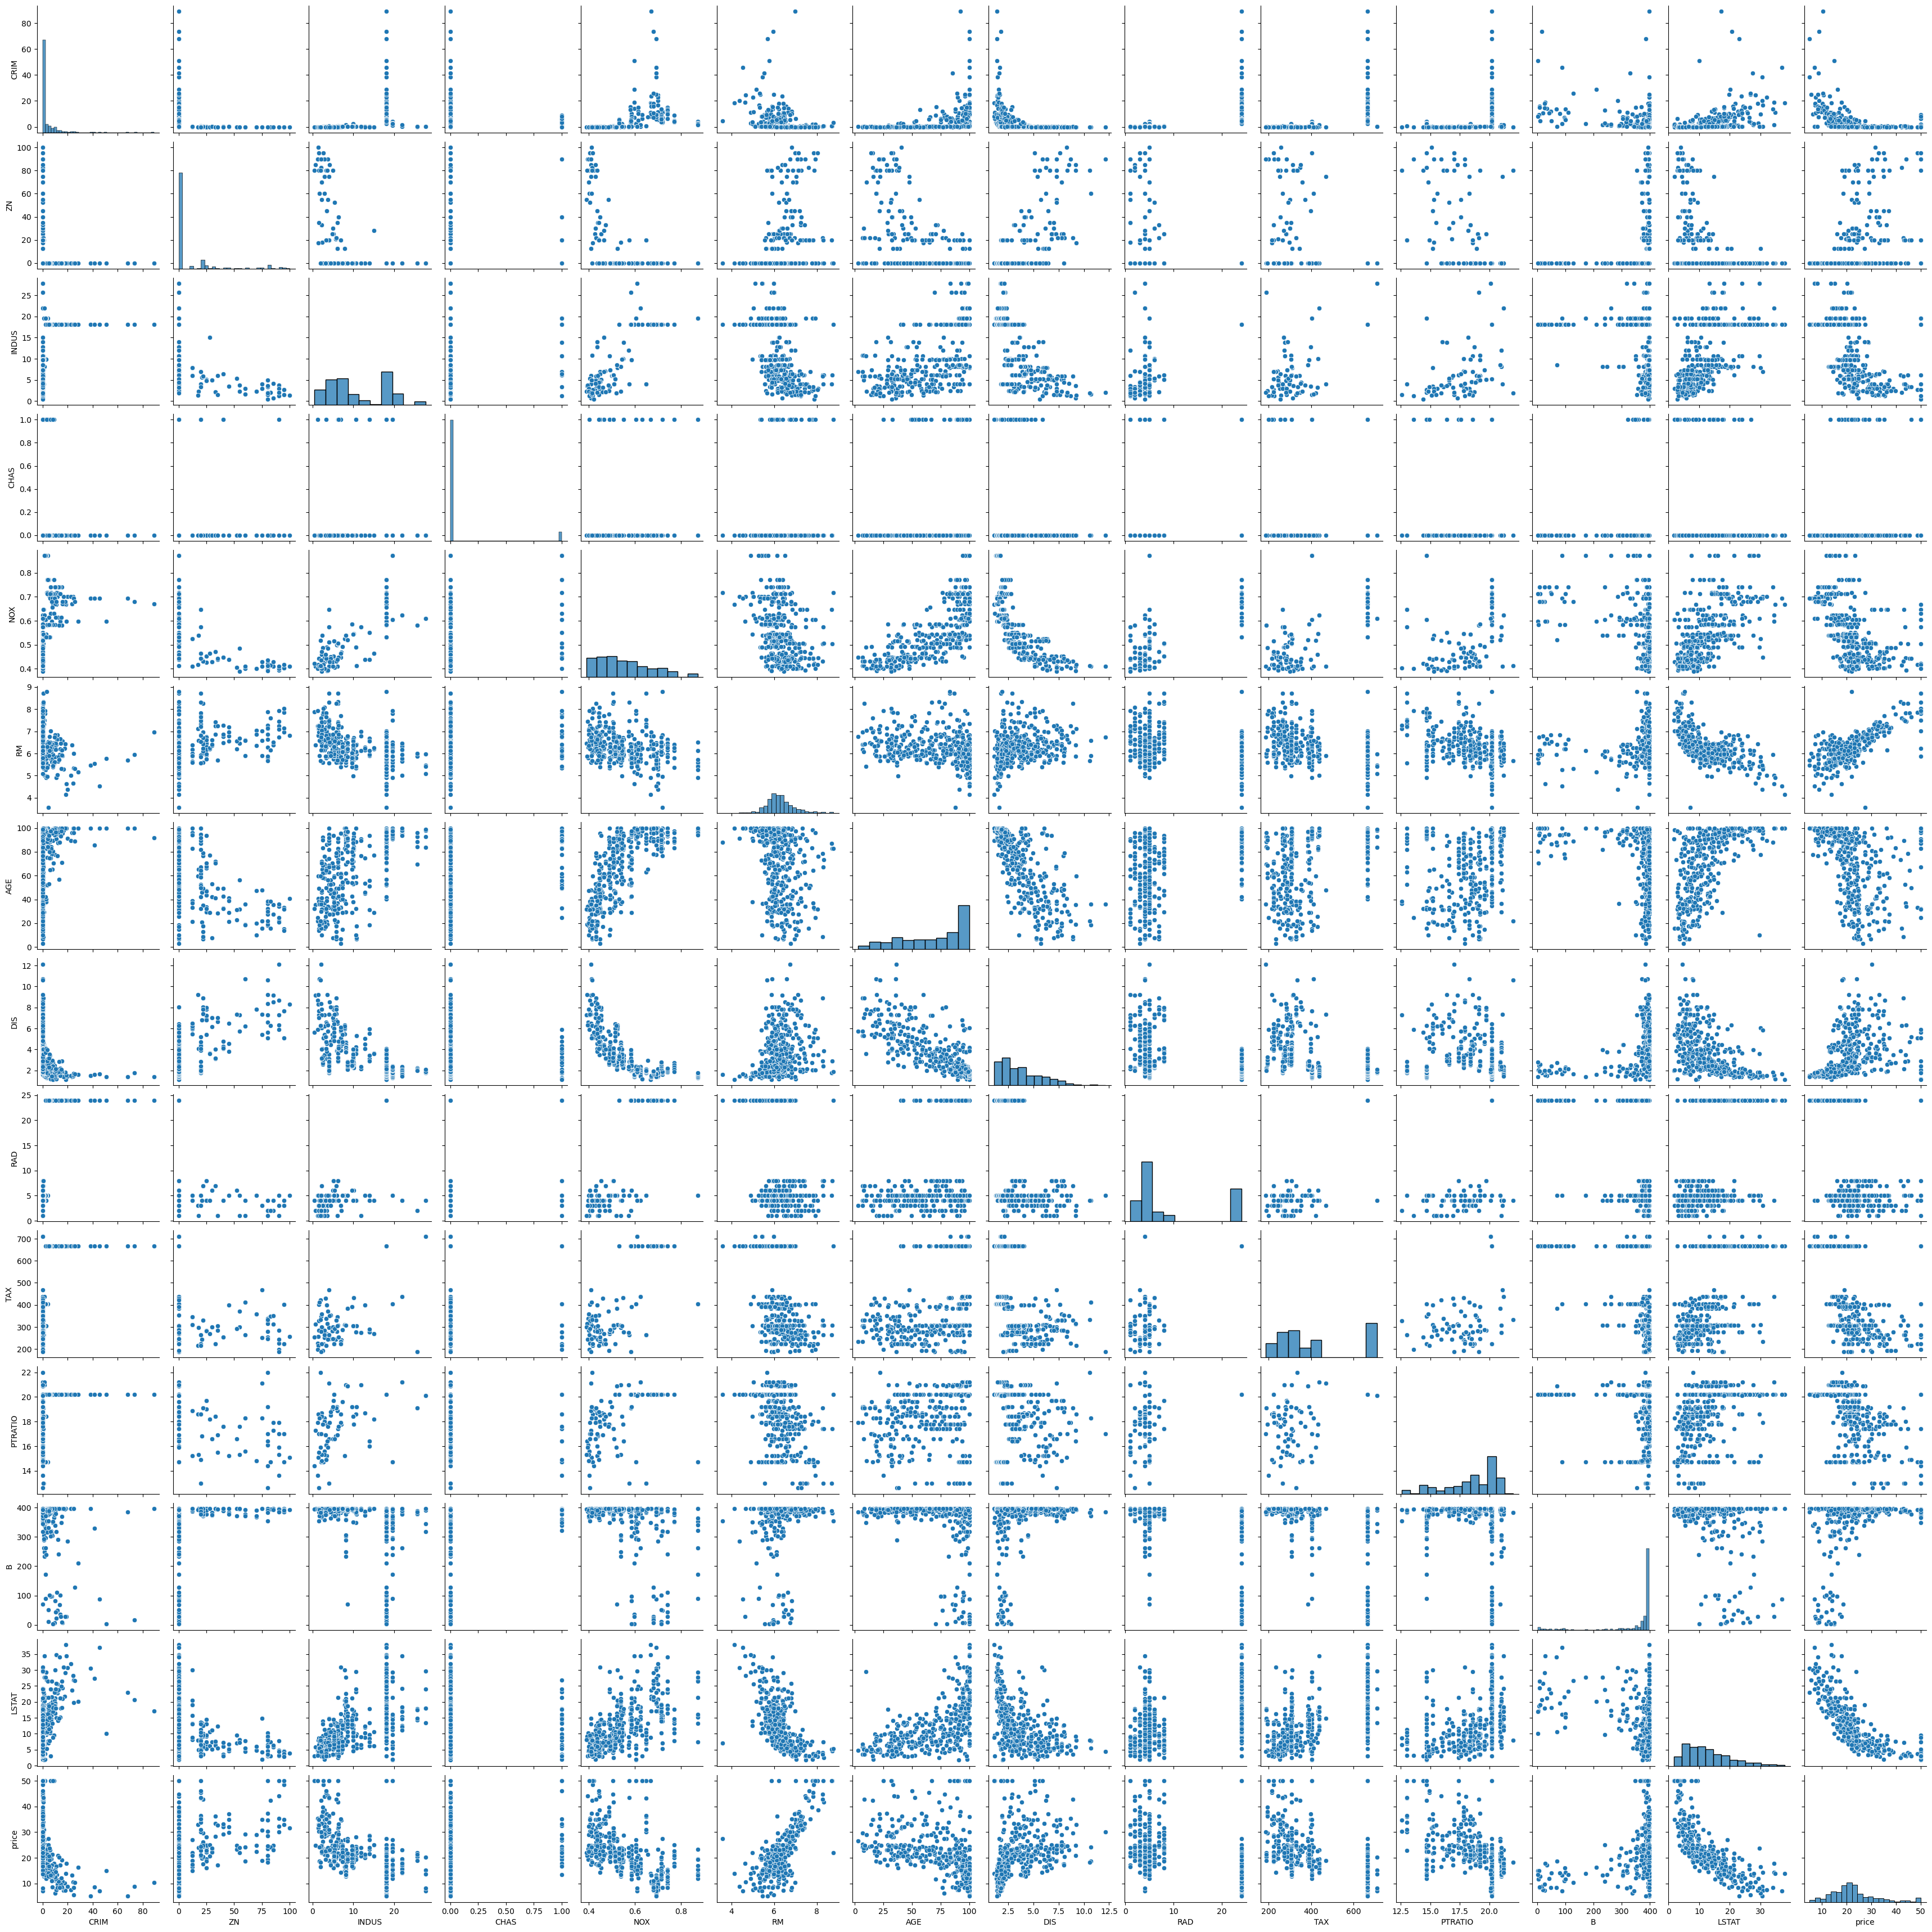

In [11]:
sns.pairplot(df)

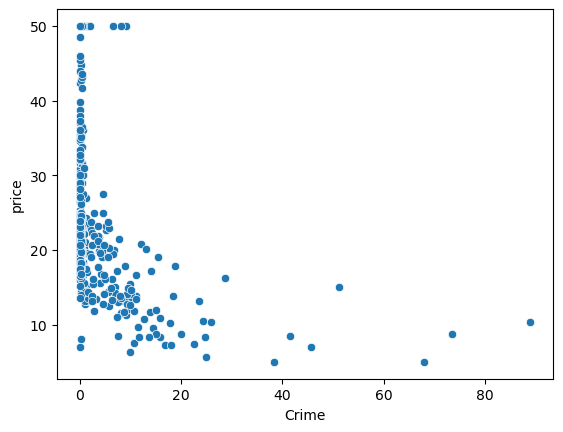

In [12]:
sns.scatterplot(x = df['CRIM'],y = df["price"])
plt.xlabel("Crime")
plt.ylabel("price")
plt.show()

In [13]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'price'],
      dtype='object')

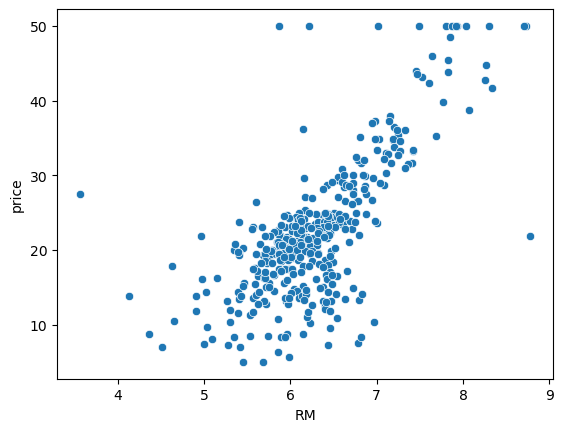

In [14]:
sns.scatterplot(x = df['RM'],y = df["price"])
plt.xlabel("RM")
plt.ylabel("price")
plt.show()

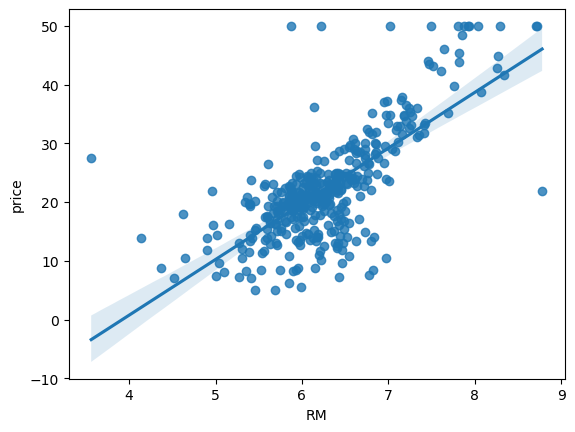

In [15]:
sns.regplot(x = df['RM'],y = df["price"])
plt.xlabel("RM")
plt.ylabel("price")
plt.show()

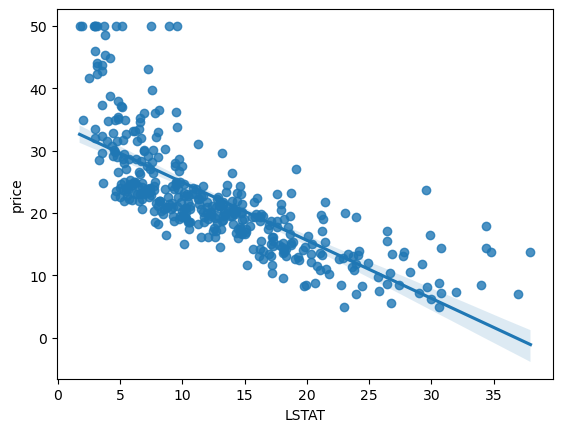

In [16]:
sns.regplot(x = df['LSTAT'],y = df["price"])
plt.xlabel("LSTAT")
plt.ylabel("price")
plt.show()

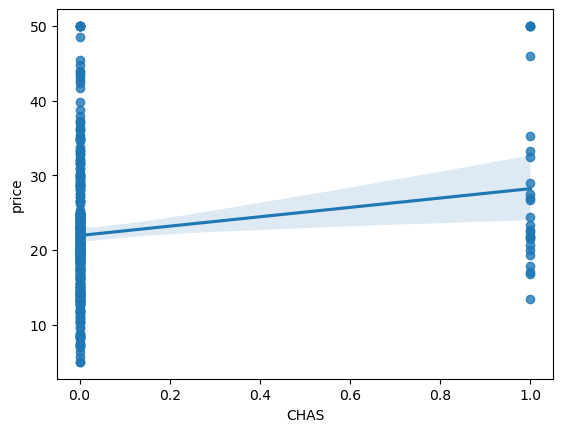

In [17]:
sns.regplot(x = df['CHAS'],y = df["price"])
plt.xlabel("CHAS")
plt.ylabel("price")
plt.show()

In [18]:
y = df["price"]
x = df.drop(columns="price")

In [19]:
x

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,0.17783,0.0,9.69,0.0,0.585,5.569,73.5,2.3999,6,391,19.2,395.77,15.10
500,0.22438,0.0,9.69,0.0,0.585,6.027,79.7,2.4982,6,391,19.2,396.90,14.33
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64


In [20]:
from sklearn.model_selection import train_test_split

In [21]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.2,random_state=42)

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [23]:
numeric_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scalling", StandardScaler())
])

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
num_col = xtrain.columns.to_list()
num_col

['CRIM',
 'ZN',
 'INDUS',
 'CHAS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT']

In [26]:
preprocessor = ColumnTransformer(transformers=[
    ("numeric_pipe",numeric_pipe,num_col)
],remainder="passthrough")

In [27]:
final_pip = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("Linear model", LinearRegression())
])
final_pip

,steps,"[('preprocessor', ...), ('Linear model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric_pipe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
final_pip.fit(xtrain, ytrain)

,steps,"[('preprocessor', ...), ('Linear model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric_pipe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
ypred = final_pip.predict(xtest)

In [30]:
ypred

array([29.22850199, 17.5037472 , 21.80803847, 30.4942528 , 18.50265527,
       34.7432311 , 22.07369779, 30.7541295 , 33.52029866, 14.82910783,
       22.14507214, 41.26427356, 22.51242483, 16.87300668, 19.0023074 ,
       20.77110711, 17.26921288, 15.48568273, 22.69482862, 14.12652975,
       18.19319969, 20.48292217, 17.04235173, 29.66737037, 26.09718411,
       16.06132841, 27.09746911, 31.45656662, 22.64238912, 27.06681913,
       41.10181897, 18.21320236, 23.062681  , 17.41202659, 17.39546606,
       21.076803  , 22.38598488, 21.66963934, 22.9118984 , 20.80249561,
       27.70046219, 34.60121409, 22.25931447, 30.83868791, 35.33229137,
       19.76393425, 24.99195034, 10.39133132, 19.75538217, 25.31114768,
       21.55934818, 25.89776968, 14.23212614, 18.66822307, 18.34126683,
       24.31756905, 43.40891373, 22.87668508, 15.3452895 , 23.17268086,
       21.11796307, 21.4821572 , 14.66508216, 28.92300146, -3.71655126,
       32.60224615, 16.81628299, 31.90077457, 24.78013157, 20.11

In [31]:
from sklearn.metrics import accuracy_score, r2_score,mean_squared_error, mean_absolute_error

In [32]:
r2_score(ytest,ypred)

0.6270849941673191

In [33]:
mean_squared_error(ytest,ypred)

31.454047664950867

In [34]:
mean_absolute_error(ytest,ypred)

3.367983225154241

In [35]:
train_score = final_pip.score(xtrain,ytrain)
test_score = final_pip.score(xtest,ytest)

In [36]:
print(train_score)
print(test_score)

0.7975984643516085
0.6270849941673191


# plot scatter plot

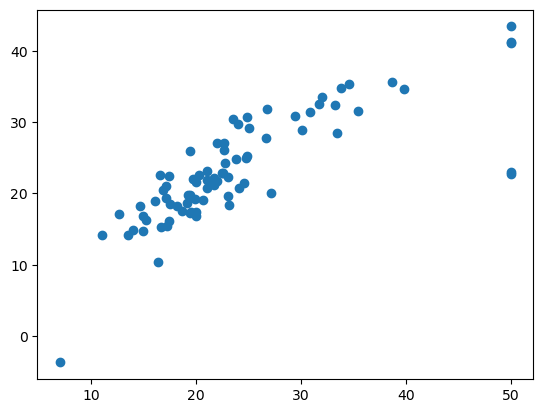

In [37]:
plt.scatter(ytest, ypred)

In [38]:
residual = ytest - ypred

In [39]:
residual

93    -4.228502
352    1.096253
319   -0.808038
65    -6.994253
499   -1.002655
         ...   
470    0.634220
97     3.092241
137   -2.247960
3      4.910175
22    -1.129636
Name: price, Length: 79, dtype: float64

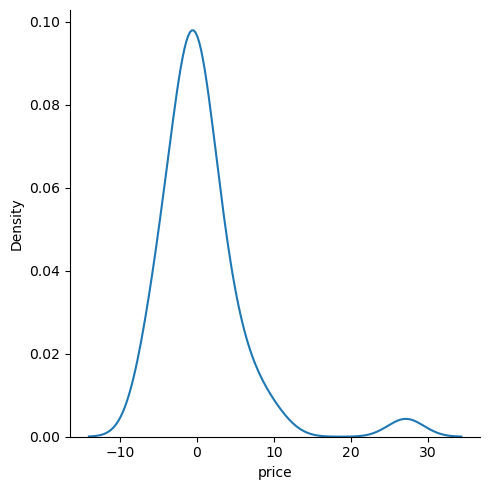

In [40]:
sns.displot(residual, kind= "kde")

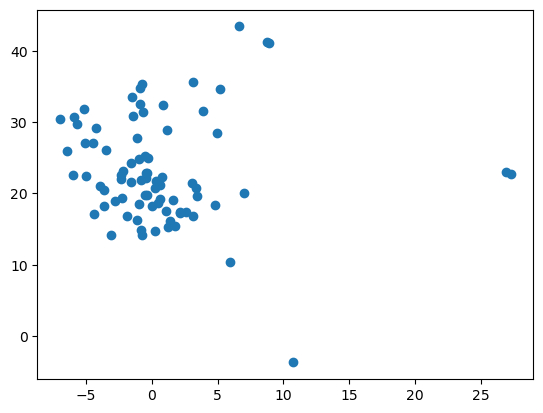

In [41]:
plt.scatter(residual,ypred)

In [45]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,0.17783,0.0,9.69,0.0,0.585,5.569,73.5,2.3999,6,391,19.2,395.77,15.10,17.5
500,0.22438,0.0,9.69,0.0,0.585,6.027,79.7,2.4982,6,391,19.2,396.90,14.33,16.8
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9


# Saving the model

In [47]:
import pickle

In [50]:
pickle.dump(final_pip,open("linear_model.pkl","wb"))

In [51]:
pickel_load = pickle.load(open("linear_model.pkl","rb"))